# Single-site traces

author: laquitainesteeve@gmail.com

Plot single-electrode voltage traces

Execution time: 20 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

Resources required:
- 180 GB RAM

## Setup

Prerequisites:

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download recordings: "_notebooks/0_download_recordings.ipynb_"


In [1]:
# setup packages
%load_ext autoreload
%autoreload 2
import os
from os.path import join
import numpy as np
from matplotlib import pyplot as plt
import spikeinterface as si
from spikeinterface import preprocessing as spre
import yaml
import warnings
import matplotlib as mpl
import pandas as pd

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")
print("Spikeinterface:", si.__version__)

# move to project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias"
os.chdir(proj_path)

# spikebias package
from src.nodes.validation import noise

# SETUP PARAMETERS
FREQ_MIN = 300         # high-pass filtering cutoff frequency
REC_DURATION_SEC = 600 # duration of recording examined
LAYER = "L5"           # layer 5
DURATION = 1.01        # period examined in figure
SF_h = 20000       # sampling frequency of dense biophy model

YLIM = (-100, 30)
GAIN_TO_UV = 0.195

# in vivo horvath dense probe data
RAW_PATH_h2 = "dataset/00_raw/recording_horvath_probe2"

# setup figure parameters
COMPUTE_FIG_DATA = False
SAVE_FIG_DATA = False
LOAD_FIG_DATA = True
SAVE_FIG = True

# get paths of saved figures
with open(join(proj_path, "conf/figures.yml"), "r", encoding="utf-8") as yaml_file:
    fig_data_paths = yaml.load(yaml_file, Loader=yaml.FullLoader)

# figure settings
FIG_SIZE = (0.9, 0.7)

# colors
COLOR_HV = [0.3, 0.3, 0.3]

# axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6
plt.rcParams["lines.linewidth"] = 0.5
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 
plt.rcParams["xtick.minor.width"] = 0.5 
plt.rcParams["ytick.major.width"] = 0.5 
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# keeps text as text in saved svg
mpl.rcParams['svg.fonttype'] = 'none' 

# legend
savefig_cfg = {"transparent":True, "dpi":300}
legend_cfg = {"frameon": False, "handletextpad": 0.1}
tight_layout_cfg = {"pad": 0.5}
LG_FRAMEON = False              # no legend frame

Spikeinterface: 0.100.8


## Clear RAM

In [2]:
import getpass; password = getpass.getpass("Enter your sudo password: ")
!sync; echo {password} | sudo -S sh -c 'echo 1 > /proc/sys/vm/drop_caches'

[sudo] password for steeve: 

## Horvath

### Compute

In [3]:
%%time 

# setup parameters
LAYER = "L5"
L5_SITE = 79 
SAMPLE_START = 15868440
REC_DURATION_SEC = 900 

# takes 56 secs
if COMPUTE_FIG_DATA:
    
    # load recording
    Recording = si.load_extractor(RAW_PATH_h2)

    # set gain to uV (0.195 described in https://doi.org/10.1038/s41597-021-00970-3)
    Recording.set_channel_gains(GAIN_TO_UV)

    # get shorter dration
    Recording = Recording.frame_slice(0, int(REC_DURATION_SEC * Recording.get_sampling_frequency()))

    # preprocess
    Recording = spre.highpass_filter(Recording, freq_min=FREQ_MIN)
    Recording = spre.common_reference(Recording, reference='global', operator='median')

    # get site id
    layers = Recording.get_property("layers")
    site = np.where(layers == LAYER)[0][L5_SITE]

    # extract traces
    traces = Recording.get_traces(channel_ids=[str(site)], return_scaled=True)

    # extract a one-second period
    one_sec_period = np.arange(SAMPLE_START, SAMPLE_START + Recording.get_sampling_frequency(), 1).astype(int)

    # extract site trace within period
    fig_data = traces[one_sec_period, :]

# save figure data
if SAVE_FIG_DATA:
    
    wind_end = int(np.floor(len(traces)/SF_h))
    bkg_noise = noise.measure_trace_noise(traces[one_sec_period.astype(int)], int(SF_h), wind_end)
    np.save(fig_data_paths["fig2e_compo_vivo_horv_bkg_noise"], bkg_noise)    
    np.save(fig_data_paths["fig2e_compo_vivo_horv"], fig_data)

# load figure data
elif LOAD_FIG_DATA:
    
    bkg_noise = np.load(fig_data_paths["fig2e_compo_vivo_horv_bkg_noise"])
    fig_data = np.load(join(proj_path, fig_data_paths["fig2e_compo_vivo_horv"])).flatten()
    print("loaded figure data")
    print("nb of 1-sec windows:", len(bkg_noise))
    print("Background noise level (min MAD over windows):", min(bkg_noise))

loaded figure data
nb of 1-sec windows: 3688
Background noise level (min MAD over windows): 79.58119
CPU times: user 704 µs, sys: 0 ns, total: 704 µs
Wall time: 881 µs


### plot

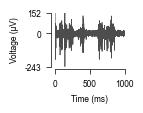

In [4]:
# plot
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE)

# plot data
ax.plot(fig_data, color=COLOR_HV)

# formatting
ax.spines[["right", "top"]].set_visible(False)
ax.set_ylabel("Voltage (\u03bcV)")
ax.set_xlabel("Time (ms)")
ax.set_xticks([0, SF_h / 2, SF_h], [0, 500, 1000])
ax.set_xlim([0, SF_h])
ax.set_yticks([-243, 0, 152], [-243, 0, 152])
ax.set_ylim([-243, 152])
ax.spines["bottom"].set_position(("axes", -0.05))
ax.yaxis.set_ticks_position("left")
ax.spines["left"].set_position(("axes", -0.05))

# save
if SAVE_FIG:
    plt.savefig("figures/8_source_data/fig2e/fig2e.svg", bbox_inches="tight")

### Save source data file

In [5]:
# time
time_ms = np.linspace(0, 1000, SF_h, endpoint=True)

# save to Excel
df = pd.DataFrame({"time_ms": time_ms, "signal": fig_data})
df.to_excel("figures/8_source_data/fig2e/fig2e.xlsx", index=False)